In [1]:
import numpy as np
import torch
from PIL.Image import Image, open as open_image
from utils.vision.embeddings.image_vector_store import (
    ImageVectorStore,
    load_image_vector_store,
    PromptImageDocument
)
from utils.vision.embeddings.imgbeddings_pipeline import (
    ImgbeddingsPipeline,
    Imgbeddings,
)
from utils.vision.embeddings.dino_pipeline import DinoPipeline
from utils.vision.embeddings.vit_pipeline import VitPipeline

from utils.vision.seg_gpt.helpers import load_model
from utils.vision.seg_gpt.model import SegGPT, seg_gpt_pretrained_model_builder
from utils.vision.seg_gpt import SegGPT_Inference
from pathlib import Path
import typing as t

In [2]:
store = load_image_vector_store('data/cache/rugd_vit.pkl')

In [3]:
#plot images with similarity
from matplotlib import pyplot as plt
import matplotlib.image as mpimg

def plot_images(img1: Image, img2: Image, similarity: float):
    fig, ax = plt.subplots(1, 2, figsize=(10, 10))
    ax[0].imshow(img1)
    ax[0].set_title('query image')
    
    ax[1].imshow(img2)
    ax[1].set_title('prompt image | similarity: {:.2f}'.format(float(similarity)))

    
    plt.show()

In [4]:
store.documents[0].image_path

PosixPath('data/examples/offroad/rugd_images_all/0001.png')

In [5]:
embedding_pipeline = VitPipeline()

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.
Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['vit.pooler.dense.bias', 'vit.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
img = open_image(store.documents[0].image_path)
embedding = embedding_pipeline(img)

In [7]:
similarity = torch.nn.CosineSimilarity()

In [8]:
test = open_image('data/examples/offroad/rugd_images_all/0031.png')
query = open_image('data/examples/offroad/rugd_images_all/1057.png')


In [9]:
store._documents[984].image_path

PosixPath('data/examples/offroad/rugd_images_all/1055.png')

In [10]:
store._documents[21].image_path

PosixPath('data/examples/offroad/rugd_images_all/0031.png')

In [11]:
store._documents[10].id

10

In [12]:
for doc in store.documents:
    if doc.image_path == 'data/examples/offroad/rugd_images_all/0031.png':
        print(doc.id)
        break 

In [13]:
store.documents[984].image_path

PosixPath('data/examples/offroad/rugd_images_all/1055.png')

In [14]:
for i, doc in enumerate(store._documents):
    print(i, doc.id, doc.image_path)

0 0 data/examples/offroad/rugd_images_all/0001.png
1 1 data/examples/offroad/rugd_images_all/0010.png
2 2 data/examples/offroad/rugd_images_all/0011.png
3 3 data/examples/offroad/rugd_images_all/0012.png
4 4 data/examples/offroad/rugd_images_all/0013.png
5 5 data/examples/offroad/rugd_images_all/0014.png
6 6 data/examples/offroad/rugd_images_all/0015.png
7 7 data/examples/offroad/rugd_images_all/0016.png
8 8 data/examples/offroad/rugd_images_all/0017.png
9 9 data/examples/offroad/rugd_images_all/0018.png
10 10 data/examples/offroad/rugd_images_all/0019.png
11 11 data/examples/offroad/rugd_images_all/0020.png
12 12 data/examples/offroad/rugd_images_all/0021.png
13 13 data/examples/offroad/rugd_images_all/0022.png
14 14 data/examples/offroad/rugd_images_all/0023.png
15 15 data/examples/offroad/rugd_images_all/0024.png
16 16 data/examples/offroad/rugd_images_all/0025.png
17 17 data/examples/offroad/rugd_images_all/0026.png
18 18 data/examples/offroad/rugd_images_all/0027.png
19 19 data/ex

In [15]:
store._documents[0].id

0

In [16]:
query_embedding = embedding_pipeline(query)
test_embedding = embedding_pipeline(test)
similarity(torch.Tensor(query_embedding), torch.Tensor(test_embedding))

tensor([0.2028])

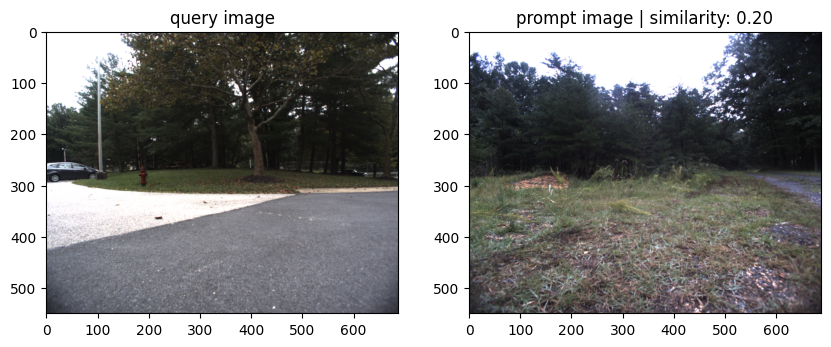

In [17]:
plot_images(query, test, similarity(torch.Tensor(query_embedding), torch.Tensor(test_embedding)))